In [ ]:
import os, shutil, pickle, warnings, logging, optuna
from functools import partial
import numpy as np, pandas as pd, xarray as xr
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib.dates as mdates
from scipy.stats import qmc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, WhiteKernel, ConstantKernel as C
)
from optuna.importance import MeanDecreaseImpurityImportanceEvaluator
from optuna.pruners import MedianPruner
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore', category=UserWarning)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [2]:
def remove_rolling_outliers(df: pd.DataFrame, column: str, window: int=20, n_std: float=3.0) -> pd.DataFrame:
    df_clean = df.copy()
    rolling_mean = df_clean[column].rolling(window=window, center=True, min_periods=3).mean()
    rolling_std = df_clean[column].rolling(window=window, center=True, min_periods=3).std()
    lower = rolling_mean - n_std * rolling_std
    upper = rolling_mean + n_std * rolling_std
    mask = (df_clean[column] >= lower) & (df_clean[column] <= upper) | df_clean[column].isna()
    return df_clean[mask].copy()

In [8]:
d, time_col = '5', 'Time'
obs_df = pd.read_csv(r'backend\projects\vlnguyen\3_MonthBest\calibration\obs_Profiler.csv')
df_sim = pd.read_csv(r'backend\projects\vlnguyen\3_MonthBest\calibration\summary\sim_1.csv')
obs_col, sim_col = f"obs_{d}", f"sim_{d}"
obs_series = obs_df[[time_col, obs_col]].dropna().set_index(time_col).sort_index()
obs_series = obs_series[~obs_series.index.duplicated(keep='first')]
obs_clean = remove_rolling_outliers(obs_series, obs_col)
df_sim = df_sim.set_index(time_col)
comb = df_sim[[sim_col]].reindex(df_sim.index.union(obs_clean.index)).sort_index()
comb[sim_col] = comb[sim_col].interpolate(method="time")
aligned = comb.loc[obs_clean.index, [sim_col]].join(obs_clean).dropna()

ValueError: time-weighted interpolation only works on Series or DataFrames with a DatetimeIndex

In [7]:
df_sim

,Time,sim_5,sim_10,sim_30,sim_40,sim_50
0,2024-03-26 11:40:00,3.000000,3.000000,3.000000,3.000000,3.000000
1,2024-03-26 17:40:00,3.111715,3.047639,3.000847,3.000000,3.000000
2,2024-03-26 23:40:00,3.038366,3.028601,3.009593,3.011207,3.012816
3,2024-03-27 05:40:00,3.004121,3.021978,3.010685,3.010614,3.012559
4,2024-03-27 11:40:00,3.045523,3.045594,3.009067,3.010725,3.012351
...,...,...,...,...,...,...
327,2024-06-16 06:40:00,6.497277,6.092356,4.361651,4.021269,4.006109
328,2024-06-16 12:40:00,6.505304,6.120266,4.344392,4.020487,4.005982
329,2024-06-16 18:40:00,6.731552,6.285889,4.317152,4.018400,4.006021
330,2024-06-17 00:40:00,6.866850,6.399543,4.369208,4.020475,4.005468


In [4]:
obs_series

,obs_5
Time,
2024-04-19 14:43:45,3.254095
2024-04-20 00:08:05,3.244756
2024-04-20 12:07:58,3.262667
2024-04-21 00:08:16,3.340014
2024-04-21 12:07:53,3.415744
...,...
2024-06-15 00:07:53,12.716853
2024-06-15 12:07:48,12.492455
2024-06-16 00:08:02,12.715203


In [5]:
obs_clean

,obs_5
Time,
2024-04-19 14:43:45,3.254095
2024-04-20 00:08:05,3.244756
2024-04-20 12:07:58,3.262667
2024-04-21 00:08:16,3.340014
2024-04-21 12:07:53,3.415744
...,...
2024-06-15 00:07:53,12.716853
2024-06-15 12:07:48,12.492455
2024-06-16 00:08:02,12.715203


In [6]:
df_sim.index.union(obs_clean.index)

Index([                    0,                     1,                     2,
                           3,                     4,                     5,
                           6,                     7,                     8,
                           9,
       ...
       '2024-06-12 12:07:53', '2024-06-13 00:07:59', '2024-06-13 12:07:49',
       '2024-06-14 00:07:58', '2024-06-14 12:07:46', '2024-06-15 00:07:53',
       '2024-06-15 12:07:48', '2024-06-16 00:08:02', '2024-06-16 12:07:48',
       '2024-06-17 00:08:02'],
      dtype='object', length=450)

In [51]:
# Setup functions
def generate_lhs_samples(parameters_range, n_samples, seed=42):
    param_names = list(parameters_range.keys())
    sampler = qmc.LatinHypercube(d=len(param_names), seed=seed, optimization='random-cd')
    sample_lhs = sampler.random(n=n_samples)
    lower_bounds = [parameters_range[p][0] for p in param_names]
    upper_bounds = [parameters_range[p][1] for p in param_names]
    sample_scaled = qmc.scale(sample_lhs, lower_bounds, upper_bounds)
    return pd.DataFrame(sample_scaled, columns=param_names, index=np.arange(1, n_samples + 1))

def modify_mdu_key(mdu_lines: list, key: str, value: str = '') -> list:
    mdu = mdu_lines.copy()
    index, line = next((i, line) for i, line in enumerate(mdu) if line.strip().startswith(key))
    new = line.split('=')
    new1 = new[1].split('#')
    mdu[index] = f'{new[0]}= {value.ljust(len(new1[0])-2)} #{new1[1]}'
    return mdu

# Remove outliers from the measured data using rolling window method
def remove_rolling_outliers(df: pd.DataFrame, column: str, window: int = 20, n_std: float = 3.0) -> pd.DataFrame:
    df_clean = df.copy()
    rolling_mean = df_clean[column].rolling(window=window, center=True, min_periods=3).mean()
    rolling_std = df_clean[column].rolling(window=window, center=True, min_periods=3).std()
    lower = rolling_mean - n_std * rolling_std
    upper = rolling_mean + n_std * rolling_std
    mask = (df_clean[column] >= lower) & (df_clean[column] <= upper) | df_clean[column].isna()
    return df_clean[mask].copy()

def compute_weighted_rmse(depths: list, rmse_list: list, method: str = 'equal') -> float:
    if method not in {"equal", "surface", "deep"}:
        raise ValueError(
            f"Unknown weighting method: {method}. "
            "Choose 'equal', 'surface', or 'deep'."
        )
    depth_arr, rmse_arr = np.array(depths), np.array(rmse_list)
    valid = np.isfinite(depth_arr) & np.isfinite(rmse_arr) & (rmse_arr >= 0)
    if not valid.any(): return np.nan
    v_depths, v_rmse = depth_arr[valid], rmse_arr[valid]
    if method == 'surface': weights = 1.0 / v_depths
    elif method == 'deep': weights = v_depths
    elif method == 'equal': weights = np.ones(len(v_depths))
    weights = weights / weights.sum()
    score = np.sqrt(np.sum(weights * v_rmse ** 2))
    return score

def interpolate_profile_to_depths(group, depths):
    g = group.sort_values("depth").drop_duplicates("depth").reset_index(drop=True)
    d_arr, t_arr = g["depth"].to_numpy(), g["temperature"].to_numpy()
    if len(d_arr) < 2: return pd.DataFrame()
    t_start = g["TIMESTAMP"].iloc[0]
    dt_sec = (g["TIMESTAMP"] - t_start).dt.total_seconds().to_numpy()
    rows = []
    for d in depths:
        if d_arr.min() <= d <= d_arr.max():
            temp_interp = float(np.interp(d, d_arr, t_arr))
            el_sec = float(np.interp(d, d_arr, dt_sec))
            ts = t_start + pd.to_timedelta(el_sec, unit="s").round("1s")
            row = {"TIMESTAMP": ts}
            for depth_col in depths:
                row[f"obs_{depth_col}"] = temp_interp if depth_col == d else np.nan
            rows.append(row)
    return pd.DataFrame(rows)

def run(mdu_path, path, dir):
    bat_path = os.path.normpath(os.path.join(dir, r"backend\softs\x64\dflowfm\scripts\run_dflowfm.bat"))
    new_path = os.path.normpath(os.path.join(dir, mdu_path))
    command = ["cmd.exe", "/c", bat_path, "--autostartstop", new_path]
    print("=" * 80)
    print(f"[STARTING] {mdu_path}")
    print("=" * 80)
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, encoding="utf-8", errors="replace", bufsize=1, cwd=path)
    error_detected = False
    # Stream logs
    for line in process.stdout:
        line = line.strip()
        if not line: continue
        print(line)
        # Catch error messages
        if "forrtl:" in line.lower() or "error" in line.lower(): error_detected = True
    return_code = process.wait()
    print("=" * 80)
    if return_code == 0 and not error_detected:
        print(f"[COMPLETED] {mdu_path}")
        print("=" * 80)
        return True
    else:
        print(f"[FAILED] {mdu_path}, exit code={return_code}")
        print("=" * 80)
        return False

def read_and_interpolate_his(case_output_dir, station_name, depths):
    his_file = os.path.join(case_output_dir, 'output', 'FlowFM_his.nc')
    if not os.path.exists(his_file): return pd.DataFrame()
    with xr.open_dataset(his_file) as ds:
        names = [n.decode('utf-8').strip() if isinstance(n, bytes) else str(n).strip() for n in ds['station_name'].values]
        if station_name not in names: return pd.DataFrame()
        st_idx = names.index(station_name)
        t_his = ds['temperature'].isel(stations=st_idx).values
        z_his = ds['zcoordinate_c'].isel(stations=st_idx).values
        wl_his = ds['waterlevel'].isel(stations=st_idx).values
        sim_times = pd.to_datetime(ds['time'].values)
    n_steps = len(sim_times)
    sim_interp = np.full((n_steps, len(depths)), np.nan)
    for i in range(n_steps):
        t_row, z_row, wl = t_his[i, :], z_his[i, :], wl_his[i]
        tgt_elev = wl - np.asarray(depths)
        mask = np.isfinite(t_row) & np.isfinite(z_row)
        if mask.sum() >= 2:
            z_valid, t_valid = z_row[mask], t_row[mask]
            order = np.argsort(z_valid)
            z_sorted, t_sorted = z_valid[order], t_valid[order]
            in_bounds = (tgt_elev >= z_sorted.min()) & (tgt_elev <= z_sorted.max())
            sim_interp[i, in_bounds] = np.interp(tgt_elev[in_bounds], z_sorted, t_sorted)
    df_sim = pd.DataFrame(sim_interp, columns=[f"sim_{d}" for d in depths], index=sim_times).reset_index().rename(columns={"index": "TIMESTAMP"})
    return df_sim

## Read and prepare observation

In [52]:
measured_path = r'Calibration\Profiler_modem_PFL_Step.dat'
depths_selected = [5, 10, 30, 40, 50]
measured_df = pd.read_csv(measured_path, delimiter=',', header=0, skiprows=[0, 2, 3], low_memory=False)
measured_df["TIMESTAMP"] = pd.to_datetime(measured_df["TIMESTAMP"])
measured_df["temperature"] = pd.to_numeric(measured_df["sensorParms(1)"], errors='coerce')
measured_df["depth"] = pd.to_numeric(measured_df["sensorParms(9)"], errors='coerce')
measured_df = measured_df[["TIMESTAMP", "temperature", "depth"]].dropna(subset=["TIMESTAMP"])
# Get data for the year 2024
df_2024 = measured_df[measured_df["TIMESTAMP"].dt.year == 2024].sort_values("TIMESTAMP").reset_index(drop=True)
df_2024["temperature"] = df_2024["temperature"].interpolate(method='linear', limit_direction='both')
df_2024["depth"] = df_2024["depth"].interpolate(method='linear', limit_direction='both')

# Detect measurement periods
df_2024['new_profile'] = ((df_2024["depth"] < 1.5) & (df_2024["depth"].shift(1) > 5.0))
df_2024['profile_id'] = df_2024['new_profile'].cumsum()
temp_measured = (
    df_2024.groupby("profile_id", group_keys=False)
    .apply(lambda g: interpolate_profile_to_depths(g, depths_selected))
    .reset_index(drop=True).sort_values("TIMESTAMP").reset_index(drop=True)
)

## Initial parameters

In [ ]:
mdu_template_path = r'Calibration\3_MonthBest\dflowfm\FlowFM.mdu'
base_workspace = r'C:\Users\vanln\Downloads\Hydro-AI-Platform'
test_folder = r'Calibration\test'
param_samples_file = os.path.join(test_folder, 'parameter_samples.csv')
os.makedirs(test_folder, exist_ok=True)
parameters_range = {
    # 'Secchidepth': [1.0, 20.0], 
    'Vicouv': [0.0, 0.5], 'Dicouv': [1e-4, 1e-2],
    'Dicoww': [0.0, 5e-6], 'Vicoww': [0.0, 5e-6], 
}

In [12]:
# Create Latin Hypercube Sampling (LHS) design for the parameters
n_samples = 50
df_params = generate_lhs_samples(parameters_range=parameters_range, n_samples=n_samples)
df_params.to_csv(param_samples_file)

## Create sample datasets

In [13]:
# Read mdu file
with open(mdu_template_path, 'r', encoding='utf-8', errors='ignore') as f:
    mdu_base = f.readlines()
his_interval = 3600 * 6
mdu_base = modify_mdu_key(mdu_base, 'WaqInterval', '0')
mdu_base = modify_mdu_key(mdu_base, 'RstInterval', '0')
mdu_base = modify_mdu_key(mdu_base, 'RestartFile', '')
mdu_base = modify_mdu_key(mdu_base, 'HisInterval', str(his_interval))
mdu = modify_mdu_key(mdu_base, 'Kmx', '40')
# Optimize his parameters
vars_to_keep = {'Wrihis_temperature', 'Wrihis_waterlevel_s1'}
for line in mdu_base:
    if line.strip().startswith(('Wrihis_', 'Wrimap_')) and '=' in line:
        var_name = line.split('=')[0].strip()
        val = '1' if var_name in vars_to_keep else '0'
        mdu_base = modify_mdu_key(mdu_base, var_name, val)

In [ ]:
# Create different scenarios
scenarios_dir = os.path.join(test_folder, 'scenarios')
os.makedirs(scenarios_dir, exist_ok=True)
parent_mdu_dir = os.path.dirname(mdu_template_path)
common_files = [f for f in os.listdir(parent_mdu_dir) if os.path.isfile(os.path.join(parent_mdu_dir, f)) and not f.endswith('.mdu')]
custom_meteo_params = {'CloudFactor', 'CloudOffset', 'AirTemperature'}

In [15]:
# Store different scenarios
for case_id, row in df_params.iterrows():
    case_dir = os.path.join(scenarios_dir, str(case_id))
    os.makedirs(case_dir, exist_ok=True)
    # Copy files
    for f in common_files:
        shutil.copy(os.path.join(parent_mdu_dir, f), os.path.join(case_dir, f))
    # Update MDU
    mdu_case = mdu_base.copy()
    mdu_case = modify_mdu_key(mdu_case, 'MapInterval', str(his_interval) if case_id == 1 else '0')
    for p_name, p_val in row.items():
        if p_name not in custom_meteo_params:
            val_str = f"{p_val:.5e}" if isinstance(p_val, float) else str(p_val)
            mdu_case = modify_mdu_key(mdu_case, p_name, val_str)
    with open(os.path.join(case_dir, 'FlowFM.mdu'), 'w', encoding='utf-8') as f:
        f.writelines(mdu_case)

## Run cases

In [16]:
error_cases = []
list_sorted = sorted(
    [int(x) for x in os.listdir(scenarios_dir) 
     if os.path.isdir(os.path.join(scenarios_dir, x))]
)
for case_id in list_sorted:
    c_dir = os.path.join(scenarios_dir, str(case_id))
    print(f"-> Running model: {case_id}/{n_samples}...")
    model_dir = os.path.join(test_folder, 'scenarios', str(case_id))
    model_path = os.path.join(model_dir, 'FlowFM.mdu')
    success = run(model_path, model_dir, base_workspace)
    if not success:
        print(f"Scenario {case_id} failed!")
        error_cases.append(case_id)
print(f'Number of error models: {len(error_cases)}')

-> Running model: 1/50...
[STARTING] Calibration\test\scenarios\1\FlowFM.mdu
'wmic' is not recognized as an internal or external command,
operable program or batch file.
Working directory: c:\Users\vanln\Downloads\Hydro-AI-Platform\Calibration\test\scenarios\1
D3D_HOME         : C:\Users\vanln\Downloads\Hydro-AI-Platform\backend\softs\x64\dflowfm\scripts\..\..\..
ARCH             : x64
executing: "C:\Users\vanln\Downloads\Hydro-AI-Platform\backend\softs\x64\dflowfm\scripts\..\..\..\x64\dflowfm\bin\dflowfm-cli.exe" --nodisplay --autostartstop --autostartstop C:\Users\vanln\Downloads\Hydro-AI-Platform\Calibration\test\scenarios\1\FlowFM.mdu
my_rank, numranks            0           1
* Deltares, D-Flow FM Version 1.2.177.142431, Jan 26 2023, 11:34:53
* Source: https://svn.oss.deltares.nl/repos/delft3d/branches/releases/142382/
* File creation date: 23:21:17, 30-08-2026
** INFO   : Command: "C:\Users\vanln\Downloads\Hydro-AI-Platform\backend\softs\x64\dflowfm\scripts\..\..\..\x64\dflowfm\b

## Prepare outputs

In [60]:
summary_list, obs_station, rmse_method = [], 'Profiler', 'equal'
df_params = pd.read_csv(param_samples_file, index_col=0)
for case_id in sorted([int(x) for x in os.listdir(scenarios_dir) if os.path.isdir(os.path.join(scenarios_dir, x))]):
    c_dir = os.path.join(scenarios_dir, str(case_id))
    df_sim = read_and_interpolate_his(c_dir, obs_station, depths_selected)
    if df_sim.empty: continue
    t_min = max(temp_measured["TIMESTAMP"].min(), df_sim["TIMESTAMP"].min())
    t_max = min(temp_measured["TIMESTAMP"].max(), df_sim["TIMESTAMP"].max())
    obs_sub = temp_measured[(temp_measured["TIMESTAMP"] >= t_min) & (temp_measured["TIMESTAMP"] <= t_max)]
    sim_sub = df_sim[(df_sim["TIMESTAMP"] >= t_min) & (df_sim["TIMESTAMP"] <= t_max)].set_index("TIMESTAMP")
    rmse_per_depth = []
    for d in depths_selected:
        obs_col, sim_col = f"obs_{d}", f"sim_{d}"
        obs_series = obs_sub[["TIMESTAMP", obs_col]].dropna().set_index("TIMESTAMP").sort_index()
        obs_series = obs_series[~obs_series.index.duplicated(keep='first')]
        obs_clean = remove_rolling_outliers(obs_series, obs_col)
        comb = sim_sub[[sim_col]].reindex(sim_sub.index.union(obs_clean.index)).sort_index()
        comb[sim_col] = comb[sim_col].interpolate(method="time")
        aligned = comb.loc[obs_clean.index, [sim_col]].join(obs_clean).dropna()
        if len(aligned) > 0:
            rmse_d = np.sqrt(mean_squared_error(aligned[obs_col], aligned[sim_col]))
            rmse_per_depth.append(rmse_d)
        else: rmse_per_depth.append(np.nan)
    weighted_rmse = compute_weighted_rmse(depths_selected, rmse_per_depth, rmse_method)
    row_params = df_params.loc[case_id].to_dict()
    row_params['RMSE'] = weighted_rmse
    summary_list.append(row_params)
summary_df = pd.DataFrame(summary_list).dropna(subset=['RMSE'])
summary_csv = os.path.join(test_folder, 'calibration_summary.csv')
summary_df.to_csv(summary_csv, index=False)
print(f"Đã tổng hợp kết quả 60 kịch bản:")

Đã tổng hợp kết quả 60 kịch bản:


## Correlation analysis

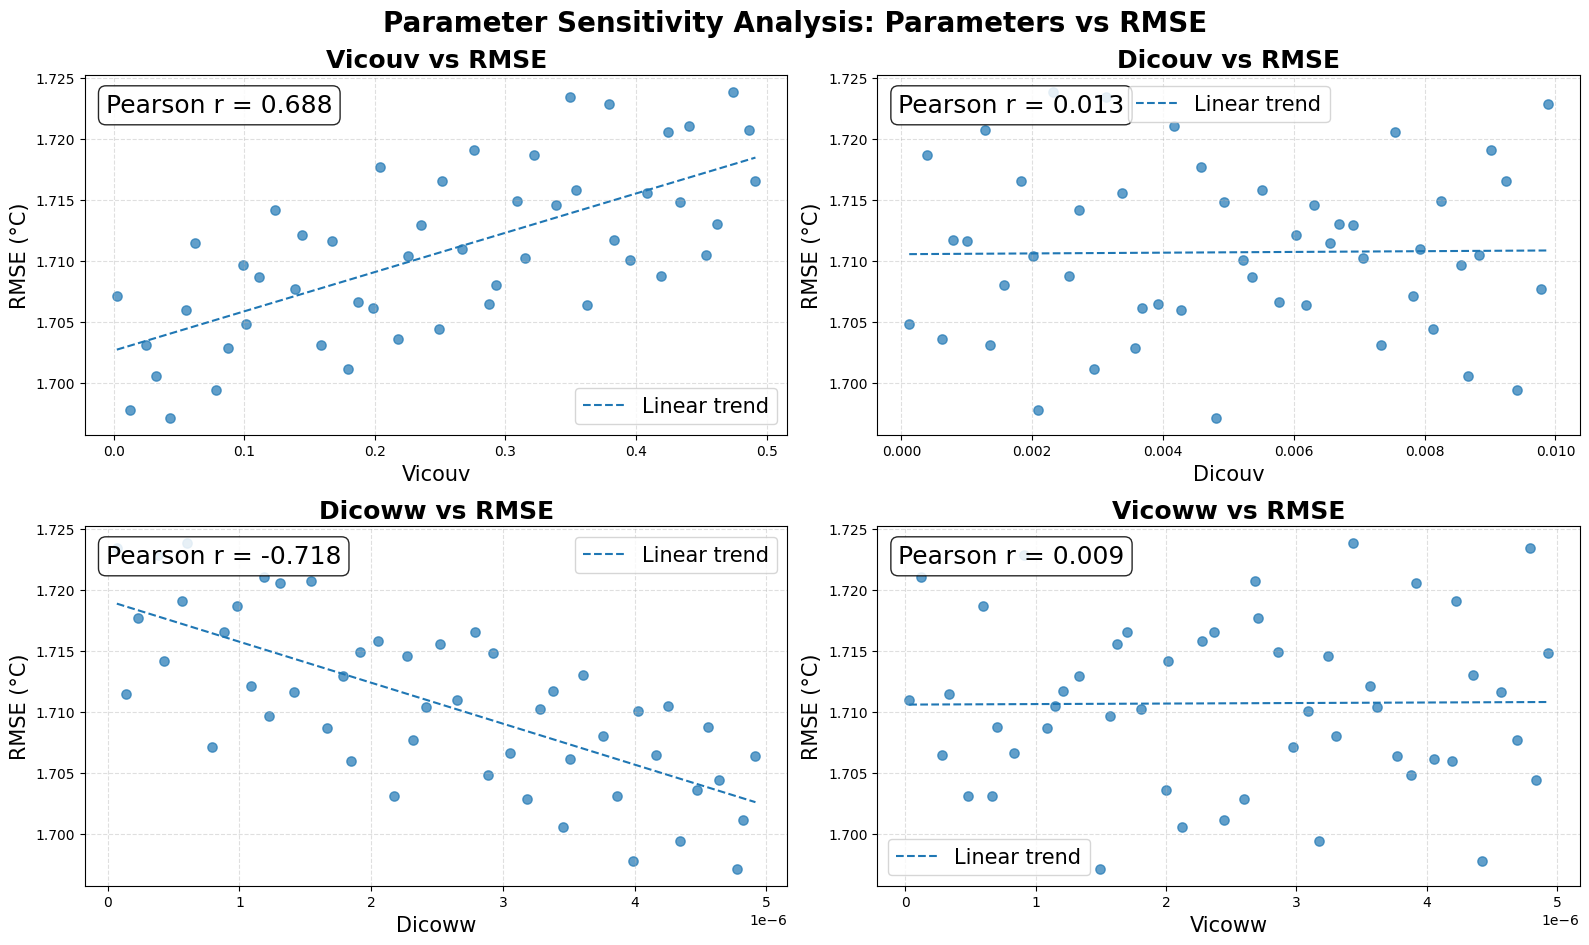

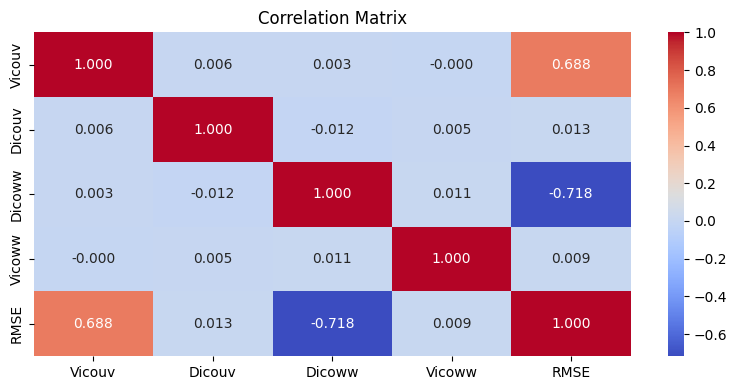

In [6]:
params, target = [x for x in summary_df.columns if x != 'RMSE'], 'RMSE'
n_plots, n_cols = len(params), 2
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.8 * n_rows))
axes = np.asarray(axes).flatten()
for idx, param in enumerate(params):
    ax = axes[idx]
    data = summary_df[[param, target]].dropna()
    x, y = data[param], data[target]
    # Scatter
    ax.scatter(x, y, s=45, alpha=0.7)
    if len(data) > 1:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(
            x_line, p(x_line), linestyle='--', linewidth=1.5, label='Linear trend'
        )
    corr = x.corr(y)
    ax.text(
        0.03, 0.95, f"Pearson r = {corr:.3f}",
        transform=ax.transAxes, va='top',
        fontsize=18,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white", alpha=0.85
        )
    )
    ax.set_title(f"{param} vs RMSE", fontweight='bold', fontsize=18)
    ax.set_xlabel(param, fontsize=15)
    ax.set_ylabel("RMSE (°C)", fontsize=15)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc='best', fontsize=15)
# Ẩn các subplot thừa
for idx in range(n_plots, len(axes)):
    axes[idx].axis('off')
plt.suptitle(
    "Parameter Sensitivity Analysis: Parameters vs RMSE",
    fontsize=20, fontweight='bold'
)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.heatmap(summary_df.corr(), annot=True, fmt='.3f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Build Surrogate model

In [12]:
X, y = summary_df.drop(columns=['RMSE']), summary_df[['RMSE']]
# Chuẩn hóa dữ liệu
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y = y.values.ravel()
# Danh sách Kernel đánh giá
kernels_to_test = [
    (C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-3, 1e2)), 'RBF'),
    (C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2)) + WhiteKernel(1e-3, (1e-10, 1e-1)), 'RBF + White'),
    (C(1.0, (1e-3, 1e3)) * Matern(1.0, nu=1.5, length_scale_bounds=(1e-3, 1e2)), 'Matern_1.5'),
    (C(1.0, (1e-3, 1e3)) * Matern(1.0, nu=2.5, length_scale_bounds=(1e-3, 1e2)), 'Matern_2.5'),
    (C(1.0, (1e-3, 1e3)) * RationalQuadratic(1.0, 1.0, length_scale_bounds=(1e-9, 1e6)), 'RationalQuadratic')
]
best_log_likelihood = -np.inf
best_kernel, cv_results = None, []
for kernel_obj, k_name in kernels_to_test:
    gpr = GaussianProcessRegressor(
        kernel=kernel_obj, n_restarts_optimizer=30, 
        alpha=1e-6, normalize_y=True, random_state=42
    )
    gpr.fit(X_scaled, y)
    if gpr.log_marginal_likelihood_value_ > best_log_likelihood:
        best_log_likelihood = gpr.log_marginal_likelihood_value_
        best_kernel, best_name = kernel_obj, k_name
print(f"Kernel tốt nhất: {best_name}")

Kernel tốt nhất: RBF + White


## Train and save model

In [15]:
final_gpr = GaussianProcessRegressor(
    kernel=kernel_obj, n_restarts_optimizer=30, 
    alpha=1e-6, normalize_y=True, random_state=42
)
final_gpr.fit(X_scaled, y)
# Lưu Model và Scaler
model_dir = os.path.join(test_folder, 'model')
os.makedirs(model_dir, exist_ok=True)
objects = [
    ('scaler_X', X_scaled), ('gpr_model', final_gpr)
]
for scaler, data in objects:
    with open(os.path.join(model_dir, f'{scaler}.pkl'), "wb") as f:
        pickle.dump(data, f)
print(f"Đã lưu mô hình Gaussian Process tại: {model_dir}")

Đã lưu mô hình Gaussian Process tại: Calibration\test\model


## Run Optuna

In [6]:
# Run optimization with Optuna
def optuna_objective(trial, scaler_x, model, p_ranges):
    trial_params = {}
    for p, bounds in p_ranges.items():
        trial_params[p] = trial.suggest_float(p, bounds[0], bounds[1])
    df_in = pd.DataFrame([trial_params], columns=list(p_ranges.keys()))
    x_sc = scaler_x.transform(df_in)
    pred_sc = model.predict(x_sc)
    return pred_sc[0]

optuna_func = partial(
    optuna_objective, scaler_x=scaler_X,
    model=final_gpr, p_ranges=parameters_range
)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    sampler=optuna.samplers.TPESampler(seed=42), direction='minimize', 
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=20),
    study_name='delft3d_fm_calibration'
)
study.optimize(optuna_func, n_trials=2000, show_progress_bar=True)
print(f"Giá trị RMSE nhỏ nhất dự đoán: {study.best_value:.4f} °C")
print(f"\nBộ tham số tối ưu khuyến nghị:")
for param_k, param_v in study.best_params.items():
    if isinstance(param_v, float) and param_v < 0.001:
        print(f"  {param_k:<20}: {param_v:.6e}")
    else: print(f"  {param_k:<20}: {param_v:.6f}")

  0%|          | 0/2000 [00:00<?, ?it/s]

Giá trị RMSE nhỏ nhất dự đoán: 1.6944 °C

Bộ tham số tối ưu khuyến nghị:
  Vicouv              : 7.403459e-05
  Dicouv              : 0.003264
  Dicoww              : 4.998101e-06
  Vicoww              : 4.998058e-06


Compute feature importance from Optuna


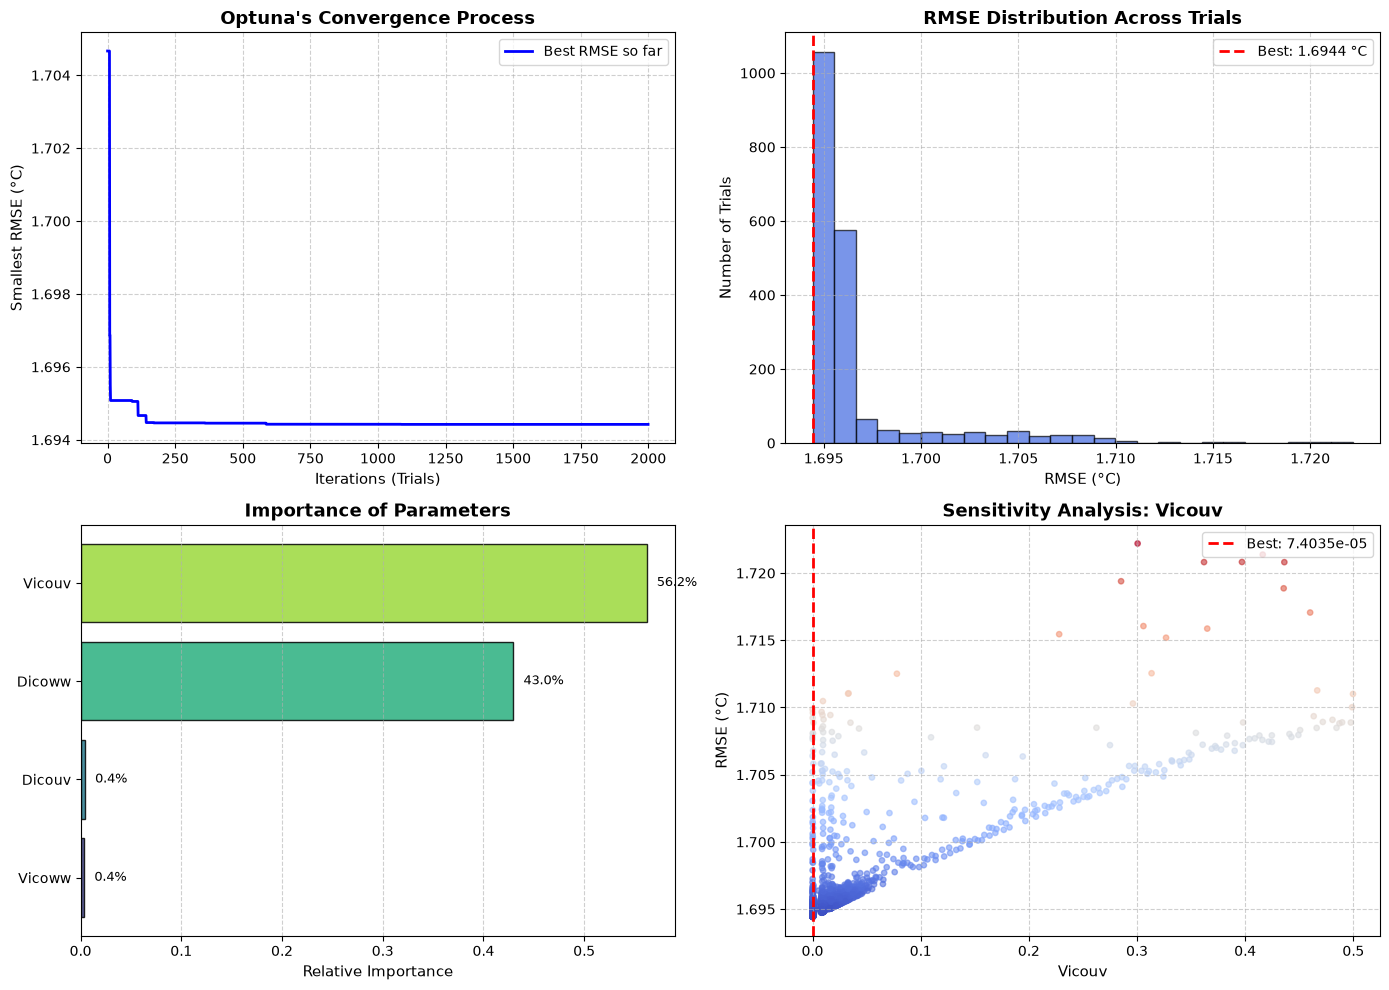

In [7]:
# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df_trials = study.trials_dataframe()
ax = axes[0, 0]
cum_min = df_trials['value'].cummin()
ax.plot(cum_min, 'b-', lw=2, label='Best RMSE so far')
ax.set_xlabel('Iterations (Trials)', fontsize=11)
ax.set_ylabel('Smallest RMSE (°C)', fontsize=11)
ax.set_title("Optuna's Convergence Process", fontsize=13, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
ax = axes[0, 1]
ax.hist(df_trials['value'].dropna(), bins=25, alpha=0.7, color='royalblue', edgecolor='black')
ax.axvline(study.best_value, color='red', linestyle='--', lw=2, label=f'Best: {study.best_value:.4f} °C')
ax.set_xlabel('RMSE (°C)', fontsize=11)
ax.set_ylabel('Number of Trials', fontsize=11)
ax.set_title('RMSE Distribution Across Trials', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
ax = axes[1, 0]
try:
    print('Compute feature importance from Optuna')
    importance = optuna.importance.get_param_importances(
        study, evaluator=MeanDecreaseImpurityImportanceEvaluator()
    )
except Exception:
    # Fallback: Tự tính feature importance bằng Random Forest từ Scikit-Learn
    print('Compute feature importance from Random Forest')
    param_cols = [c for c in df_trials.columns if c.startswith('params_')]
    X_tr = df_trials[param_cols].fillna(df_trials[param_cols].mean())
    y_tr = df_trials['value'].fillna(df_trials['value'].max())
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_tr, y_tr)
    clean_names = [c.replace('params_', '') for c in param_cols]
    importance = dict(zip(clean_names, rf.feature_importances_))

sorted_importance = dict(sorted(importance.items(), key=lambda item: item[1]))
param_names = list(sorted_importance.keys())
param_vals = list(sorted_importance.values())
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(param_names)))
bars = ax.barh(param_names, param_vals, color=colors, edgecolor='black', alpha=0.85)
ax.set_xlabel('Relative Importance', fontsize=11)
ax.set_title('Importance of Parameters', fontsize=13, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.6, axis='x')
# Hiển thị phần trăm giá trị cạnh mỗi thanh
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.1%}', 
            va='center', ha='left', fontsize=9, color='black')
ax = axes[1, 1]
# Ưu tiên chọn tham số có độ quan trọng cao nhất, hoặc mặc định là 'Secchidepth'
most_important_var = param_names[-1] if len(param_names) > 0 else 'Secchidepth'
var = most_important_var if f'params_{most_important_var}' in df_trials.columns else 'Secchidepth'
if f'params_{var}' in df_trials.columns:
    sc = ax.scatter(df_trials[f'params_{var}'], df_trials['value'], alpha=0.6, s=15, c=df_trials['value'], cmap='coolwarm')
    best_val_param = study.best_params[var]
    if abs(best_val_param) < 0.001: label_text = f"Best: {best_val_param:.4e}"
    else: label_text = f"Best: {best_val_param:.3f}"
    ax.axvline(best_val_param, color='red', linestyle='--', lw=2, label=label_text)
    ax.set_xlabel(f'{var}', fontsize=11)
    ax.set_ylabel('RMSE (°C)', fontsize=11)
    ax.set_title(f'Sensitivity Analysis: {var}', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Update new parameters and rerun Delft3D FM 

In [105]:
final_dir = os.path.join(test_folder, 'model', 'final')
if os.path.exists(final_dir):
    shutil.rmtree(final_dir)
os.makedirs(final_dir, exist_ok=True)
# Copy toàn bộ file cấu hình cơ sở (lưới, địa hình, biên...)
for f in common_files:
    shutil.copy(os.path.join(parent_mdu_dir, f), os.path.join(final_dir, f))
# 2. Cập nhật các tham số tối ưu vào file FlowFM.mdu
mdu_final = mdu_base.copy()
# Cho phép xuất MAP file cho kịch bản tối ưu để xem trực quan hóa 2D/3D
mdu_final = modify_mdu_key(mdu_final, 'MapInterval', str(his_interval))
for param_name, param_val in study.best_params.items():
    if param_name not in custom_meteo_params:
        val_str = f"{param_val:.6e}" if isinstance(param_val, float) and abs(param_val) < 0.01 else f"{param_val:.6f}"
        mdu_final = modify_mdu_key(mdu_final, param_name, val_str)
final_mdu_path = os.path.join(final_dir, 'FlowFM.mdu')
with open(final_mdu_path, 'w', encoding='utf-8') as f:
    f.writelines(mdu_final)
# Run a simulation
model_path = os.path.join(final_dir, 'FlowFM.mdu')
run_success = run(model_path, final_dir, base_workspace)
print(run_success)

[STARTING] Calibration\test\model\final\FlowFM.mdu
'wmic' is not recognized as an internal or external command,
operable program or batch file.
Working directory: c:\Users\vanln\Downloads\Hydro-AI-Platform\Calibration\test\model\final
D3D_HOME         : C:\Users\vanln\Downloads\Hydro-AI-Platform\backend\softs\x64\dflowfm\scripts\..\..\..
ARCH             : x64
executing: "C:\Users\vanln\Downloads\Hydro-AI-Platform\backend\softs\x64\dflowfm\scripts\..\..\..\x64\dflowfm\bin\dflowfm-cli.exe" --nodisplay --autostartstop --autostartstop C:\Users\vanln\Downloads\Hydro-AI-Platform\Calibration\test\model\final\FlowFM.mdu
my_rank, numranks            0           1
* Deltares, D-Flow FM Version 1.2.177.142431, Jan 26 2023, 11:34:53
* Source: https://svn.oss.deltares.nl/repos/delft3d/branches/releases/142382/
* File creation date: 12:39:23, 01-09-2026
** INFO   : Command: "C:\Users\vanln\Downloads\Hydro-AI-Platform\backend\softs\x64\dflowfm\scripts\..\..\..\x64\dflowfm\bin\dflowfm-cli.exe"  --nod

In [61]:
df_sim_final = read_and_interpolate_his(final_dir, obs_station, depths_selected)
if not df_sim_final.empty:
    t_min = max(temp_measured["TIMESTAMP"].min(), df_sim_final["TIMESTAMP"].min())
    t_max = min(temp_measured["TIMESTAMP"].max(), df_sim_final["TIMESTAMP"].max())
    obs_sub = temp_measured[(temp_measured["TIMESTAMP"] >= t_min) & (temp_measured["TIMESTAMP"] <= t_max)]
    sim_sub = df_sim_final[(df_sim_final["TIMESTAMP"] >= t_min) & (df_sim_final["TIMESTAMP"] <= t_max)].set_index("TIMESTAMP")
    performance_metrics = []
    aligned_data_dict = {}
    for d in depths_selected:
        obs_col, sim_col = f"obs_{d}", f"sim_{d}"
        obs_series = obs_sub[["TIMESTAMP", obs_col]].dropna().set_index("TIMESTAMP").sort_index()
        obs_series = obs_series[~obs_series.index.duplicated(keep='first')]
        obs_clean = remove_rolling_outliers(obs_series, obs_col)
        comb = sim_sub[[sim_col]].reindex(sim_sub.index.union(obs_clean.index)).sort_index()
        comb[sim_col] = comb[sim_col].interpolate(method="time")
        aligned = comb.loc[obs_clean.index, [sim_col]].join(obs_clean).dropna()
        aligned_data_dict[d] = aligned
        if len(aligned) > 0:
            rmse_val = np.sqrt(mean_squared_error(aligned[obs_col], aligned[sim_col]))
            mae_val = np.mean(np.abs(aligned[obs_col] - aligned[sim_col]))
            r2_val = r2_score(aligned[obs_col], aligned[sim_col])
            bias_val = np.mean(aligned[sim_col] - aligned[obs_col])
        else: rmse_val, mae_val, r2_val, bias_val = np.nan, np.nan, np.nan, np.nan
        performance_metrics.append({
            'Depth (m)': d, 'RMSE (°C)': rmse_val, 'MAE (°C)': mae_val,
            'Bias (°C)': bias_val, 'R²': r2_val, 'Data Points': len(aligned)
        })

NameError: name 'final_dir' is not defined

In [62]:
# Plot
old_sim_dir = r'Calibration\3_MonthBest\dflowfm'
df_sim_old = read_and_interpolate_his(old_sim_dir, obs_station, depths_selected)
# Đảm bảo dữ liệu mô phỏng MỚI (Tối ưu) đã được đọc
if 'df_sim_final' not in locals() or df_sim_final.empty:
    df_sim_final = read_and_interpolate_his(final_dir, obs_station, depths_selected)
# 2. Xác định khoảng thời gian chung cho cả 3 chuỗi dữ liệu
t_min = max(temp_measured["TIMESTAMP"].min(), df_sim_final["TIMESTAMP"].min(), df_sim_old["TIMESTAMP"].min())
t_max = min(temp_measured["TIMESTAMP"].max(), df_sim_final["TIMESTAMP"].max(), df_sim_old["TIMESTAMP"].max())
obs_sub = temp_measured[(temp_measured["TIMESTAMP"] >= t_min) & (temp_measured["TIMESTAMP"] <= t_max)]
sim_new_sub = df_sim_final[(df_sim_final["TIMESTAMP"] >= t_min) & (df_sim_final["TIMESTAMP"] <= t_max)].set_index("TIMESTAMP")
sim_old_sub = df_sim_old[(df_sim_old["TIMESTAMP"] >= t_min) & (df_sim_old["TIMESTAMP"] <= t_max)].set_index("TIMESTAMP")
# 3. Tính toán các chỉ số thống kê chi tiết cho từng tầng độ sâu
comparison_metrics = []
aligned_all_dict = {}
for d in depths_selected:
    obs_col, sim_col = f"obs_{d}", f"sim_{d}"
    # Lấy và lọc ngoại lai số liệu thực đo
    obs_series = obs_sub[["TIMESTAMP", obs_col]].dropna().set_index("TIMESTAMP").sort_index()
    obs_series = obs_series[~obs_series.index.duplicated(keep='first')]
    obs_clean = remove_rolling_outliers(obs_series, obs_col)
    # Căn chỉnh chuỗi mô phỏng MỚI về mốc đo
    comb_new = sim_new_sub[[sim_col]].reindex(sim_new_sub.index.union(obs_clean.index)).sort_index()
    comb_new[sim_col] = comb_new[sim_col].interpolate(method="time")
    aligned_new = comb_new.loc[obs_clean.index, [sim_col]].rename(columns={sim_col: f"sim_new_{d}"})
    # Căn chỉnh chuỗi mô phỏng CŨ về mốc đo
    comb_old = sim_old_sub[[sim_col]].reindex(sim_old_sub.index.union(obs_clean.index)).sort_index()
    comb_old[sim_col] = comb_old[sim_col].interpolate(method="time")
    aligned_old = comb_old.loc[obs_clean.index, [sim_col]].rename(columns={sim_col: f"sim_old_{d}"})
    # Gộp chung vào DataFrame
    merged = obs_clean.join(aligned_old).join(aligned_new).dropna()
    aligned_all_dict[d] = merged
    if len(merged) > 0:
        rmse_old = np.sqrt(mean_squared_error(merged[obs_col], merged[f"sim_old_{d}"]))
        rmse_new = np.sqrt(mean_squared_error(merged[obs_col], merged[f"sim_new_{d}"]))
        mae_old = np.mean(np.abs(merged[obs_col] - merged[f"sim_old_{d}"]))
        mae_new = np.mean(np.abs(merged[obs_col] - merged[f"sim_new_{d}"]))
        r2_old = r2_score(merged[obs_col], merged[f"sim_old_{d}"])
        r2_new = r2_score(merged[obs_col], merged[f"sim_new_{d}"])
        improv = ((rmse_old - rmse_new) / rmse_old) * 100.0
    else: rmse_old, rmse_new, mae_old, mae_new, r2_old, r2_new, improv = [np.nan] * 7
    comparison_metrics.append({'Depth (m)': d, 'Old RMSE (°C)': rmse_old, 'New RMSE (°C)': rmse_new,
        'Old MAE (°C)': mae_old, 'New MAE (°C)': mae_new, 'Old R²': r2_old,
        'New R²': r2_new, 'Improvement (%)': improv
    })
df_comp = pd.DataFrame(comparison_metrics)
weighted_old_rmse = compute_weighted_rmse(depths_selected, df_comp['Old RMSE (°C)'].tolist(), rmse_method)
weighted_new_rmse = compute_weighted_rmse(depths_selected, df_comp['New RMSE (°C)'].tolist(), rmse_method)
total_improv = ((weighted_old_rmse - weighted_new_rmse) / weighted_old_rmse) * 100.0
print(df_comp.to_string(index=False))
print("---------------------------------------------------------------------")
print(f">> Total RMSE (Old - Baseline)   : {weighted_old_rmse:.4f} °C")
print(f">> Total RMSE (New - Optimized)  : {weighted_new_rmse:.4f} °C")
print(f">> Improvement                   : {total_improv:+.2f} %")
print("=====================================================================\n")
# 4. Vẽ biểu đồ chuỗi thời gian so sánh đa tầng bố cục 2 cột
sns.set_theme(style="ticks")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 13,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 10, 'figure.titlesize': 15
})
n_depths = len(depths_selected)
n_cols = 2
n_rows = (n_depths + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.2 * n_rows), sharex=True)
axes = axes.flatten() if n_depths > 1 else [axes]
for idx, d in enumerate(depths_selected):
    ax = axes[idx]
    obs_col, sim_col = f"obs_{d}", f"sim_{d}"
    # 1. Đường mô phỏng CŨ (Baseline)
    if not df_sim_old.empty:
        ax.plot(df_sim_old['TIMESTAMP'], df_sim_old[sim_col], 
            label='Old Simulation (Baseline)', color='#7f7f7f', linestyle='--', linewidth=1.5, alpha=0.85)
    # 2. Đường mô phỏng MỚI (Sau hiệu chỉnh Optuna)
    if not df_sim_final.empty:
        ax.plot(df_sim_final['TIMESTAMP'], df_sim_final[sim_col], 
            label='New Simulation (Optimized)', color='#d62728', linestyle='-', linewidth=1.8, alpha=0.9)
    # 3. Điểm số liệu THỰC ĐO (Profiler)
    if d in aligned_all_dict and not aligned_all_dict[d].empty:
        merged = aligned_all_dict[d]
        ax.plot(merged.index, merged[obs_col], 
            label='Observation (Profiler)', color='#1f77b4', linestyle='-', 
            linewidth=1.4, marker='o', markersize=2.5, alpha=0.85, zorder=3)
    # Box thông tin sai số
    row_info = df_comp[df_comp['Depth (m)'] == d].iloc[0]
    box_text = (f"Old RMSE: {row_info['Old RMSE (°C)']:.2f}°C  (R²: {row_info['Old R²']:.2f})\n"
                f"New RMSE: {row_info['New RMSE (°C)']:.2f}°C (R²: {row_info['New R²']:.2f})\n"
                f"Improvement: {row_info['Improvement (%)']:+.1f}%")
    ax.text(0.02, 0.95, box_text, transform=ax.transAxes, va='top',
            fontsize=9.5, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="#cccccc"))
    ax.set_title(f"Water Depth: {d} m", fontweight='bold')
    ax.set_ylabel("Temperature (°C)")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
# Ẩn các ô trống nếu số độ sâu là số lẻ
for idx in range(n_depths, len(axes)):
    fig.delaxes(axes[idx])
plt.suptitle(f"Temperature Comparation (Station: {obs_station}) - Method for RMSE computation: {rmse_method}\n"
             f"Total RMSE: Old = {weighted_old_rmse:.3f}°C -> New = {weighted_new_rmse:.3f}°C (Improvement {total_improv:+.1f}%)", 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()
# 5. Đồ thị tương quan Parity Plot 1:1 so sánh 2 trường hợp
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), sharex=True, sharey=True)
# Lấy giá trị Min-Max
all_obs = np.concatenate([aligned_all_dict[d][f"obs_{d}"].values for d in depths_selected if d in aligned_all_dict])
all_sim_old = np.concatenate([aligned_all_dict[d][f"sim_old_{d}"].values for d in depths_selected if d in aligned_all_dict])
all_sim_new = np.concatenate([aligned_all_dict[d][f"sim_new_{d}"].values for d in depths_selected if d in aligned_all_dict])
min_v = min(all_obs.min(), all_sim_old.min(), all_sim_new.min()) - 0.5
max_v = max(all_obs.max(), all_sim_old.max(), all_sim_new.max()) + 0.5
colors = sns.color_palette("tab10", n_depths)


# Ô bên trái: Mô phỏng Cũ vs Thực đo
for idx, d in enumerate(depths_selected):
    if d in aligned_all_dict:
        m = aligned_all_dict[d]
        axes[0].scatter(m[f"obs_{d}"], m[f"sim_old_{d}"], label=f"Depth {d} m", color=colors[idx], alpha=0.5, s=20)
axes[0].plot([min_v, max_v], [min_v, max_v], 'k--', lw=1.5, label='Line 1:1')
axes[0].set_title(f"Before Calibration (Baseline)\nTotal RMSE = {weighted_old_rmse:.3f} °C", fontweight='bold')
axes[0].set_xlabel("Observation (°C)")
axes[0].set_ylabel("Simulation (°C)")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(loc='lower right', fontsize=9)
# Ô bên phải: Mô phỏng Mới vs Thực đo
for idx, d in enumerate(depths_selected):
    if d in aligned_all_dict:
        m = aligned_all_dict[d]
        axes[1].scatter(m[f"obs_{d}"], m[f"sim_new_{d}"], label=f"Depth {d} m", color=colors[idx], alpha=0.5, s=20)
axes[1].plot([min_v, max_v], [min_v, max_v], 'k--', lw=1.5, label='Line 1:1')
axes[1].set_title(f"After Calibration (Optimized)\nTotal RMSE = {weighted_new_rmse:.3f} °C", fontweight='bold')
axes[1].set_xlabel("Observation (°C)")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc='lower right', fontsize=9)
axes[0].set_xlim(min_v, max_v)
axes[0].set_ylim(min_v, max_v)
plt.tight_layout()
plt.show()

NameError: name 'final_dir' is not defined